In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded")

All libraries loaded


In [ ]:
df = pd.read_csv('netflix_titles.csv')
print(df.shape)

(8807, 12)


In [10]:

print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")
df.head()

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicates: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Dataset Summary

This dataset contains 8,807 rows and 12 columns covering Netflix movies and TV shows.
Columns include title, type, director, cast, country, date_added, release_year, rating, duration, and genre (listed_in).
The largest data quality issue is missing directors (2,634 missing) and country (831 missing) — common for older or international content.
There are no duplicate rows, so no deduplication is needed.
The data spans content from multiple decades, with release years and dates added to Netflix both present for trend analysis.

In [11]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [12]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print(df[['date_added', 'year_added', 'month_added']].head())

  date_added  year_added  month_added
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0


## Data Cleaning Decisions

1. Filled missing `director`, `cast`, `country`, `rating`, `duration` with 'Unknown'
   — dropping these rows would remove too much data.
2. Filled missing `date_added` with 'Unknown' before converting to datetime.
3. Converted `date_added` to datetime format and extracted `year_added` and `month_added`
   — needed for trend analysis.
4. No duplicates found, so no rows were dropped.

In [13]:
print("Q1: Movies vs TV Shows")
print(df['type'].value_counts())

Q1: Movies vs TV Shows
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [14]:
print("Q2: Top 10 countries")
print(df[df['country'] != 'Unknown']['country'].value_counts().head(10))

Q2: Top 10 countries
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [15]:
print("Q3: Most common ratings")
print(df[df['rating'] != 'Unknown']['rating'].value_counts())

Q3: Most common ratings
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [16]:
print("Q4: Titles added per year")
print(df['year_added'].value_counts().sort_index())

Q4: Titles added per year
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


In [17]:
print("Q5: Top 10 genres")
genres = df['listed_in'].str.split(', ').explode()
print(genres.value_counts().head(10))

Q5: Top 10 genres
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


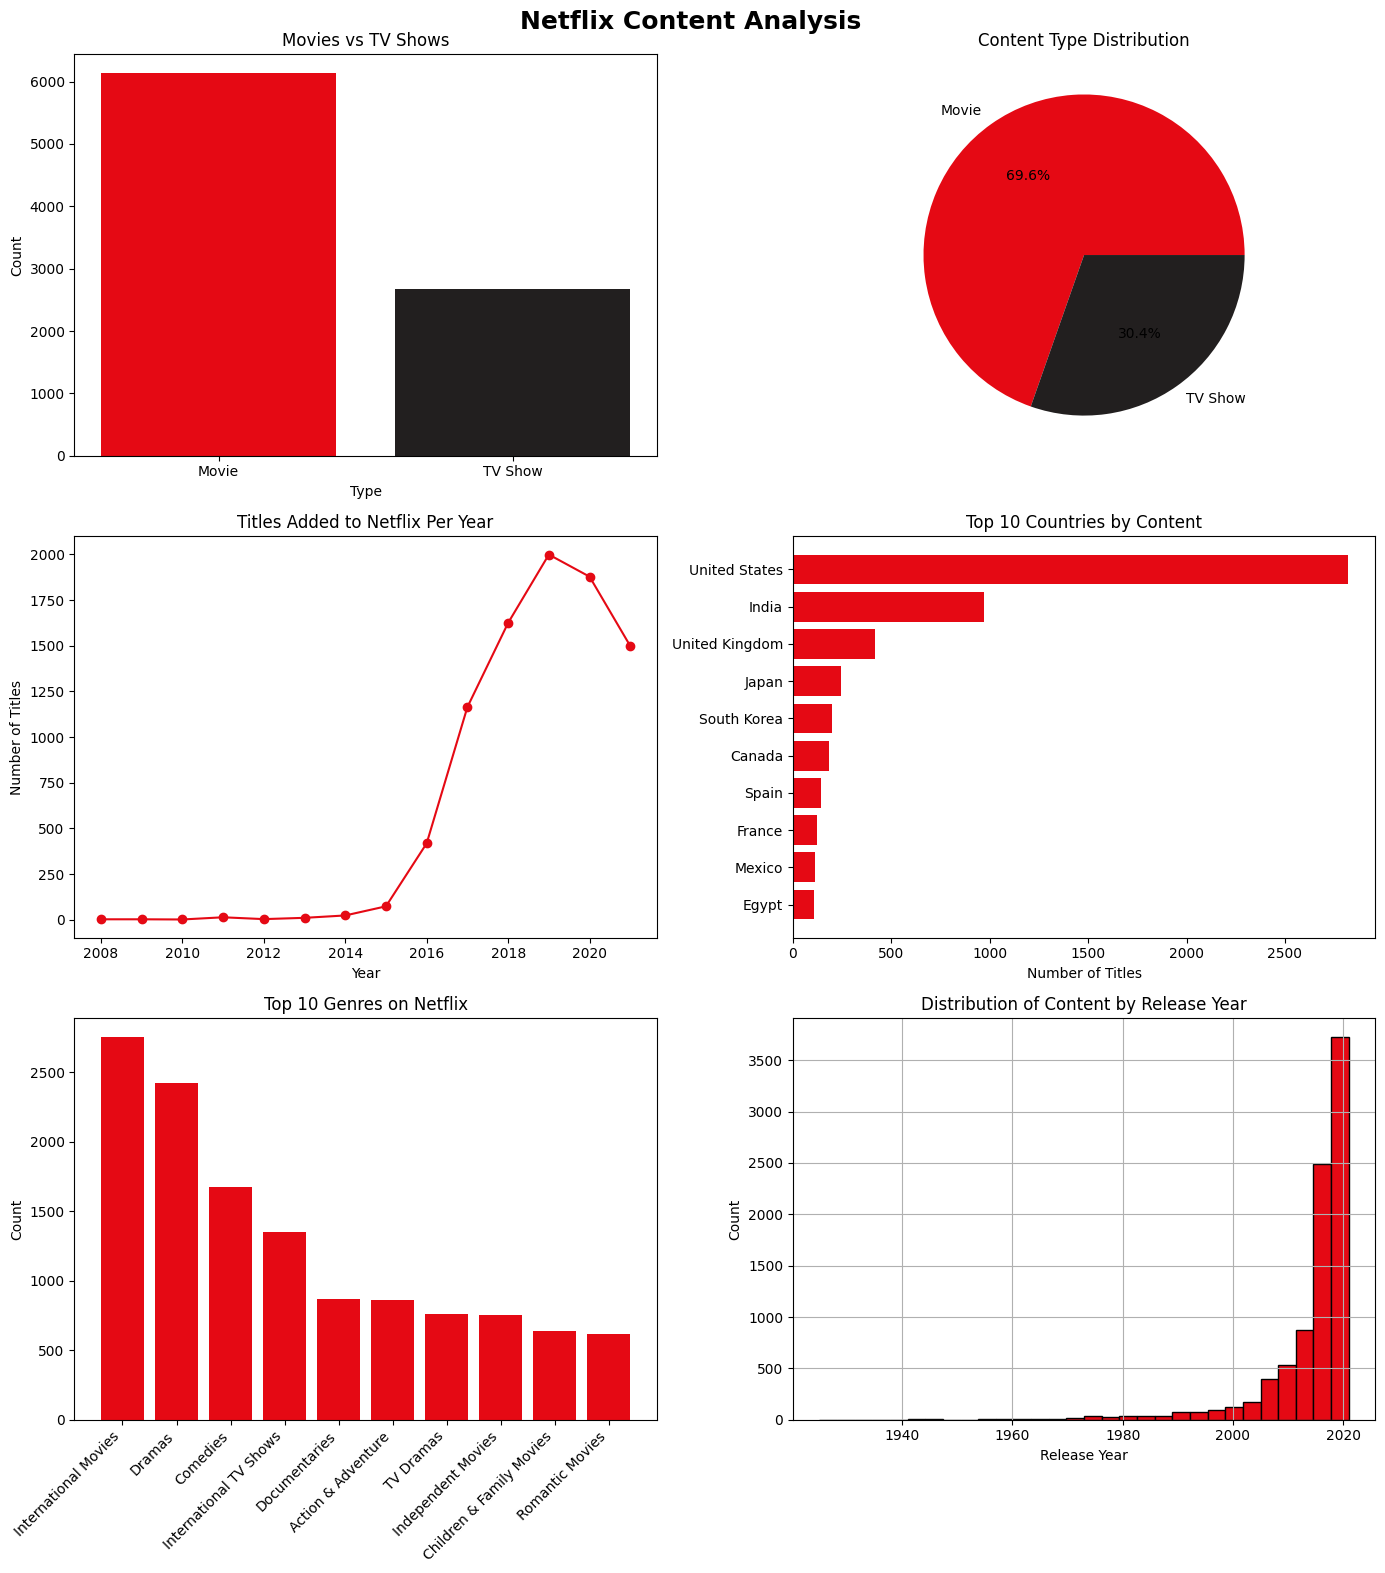

All 6 charts saved!


In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Netflix Content Analysis', fontsize=18, fontweight='bold')

# Chart 1 - Bar chart: Movies vs TV Shows
type_counts = df['type'].value_counts()
axes[0,0].bar(type_counts.index, type_counts.values, color=['#E50914','#221F1F'])
axes[0,0].set_title('Movies vs TV Shows')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Count')

# Chart 2 - Pie chart: Movies vs TV Shows ratio
axes[0,1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
              colors=['#E50914','#221F1F'])
axes[0,1].set_title('Content Type Distribution')

# Chart 3 - Line chart: Titles added per year
yearly = df['year_added'].value_counts().sort_index().dropna()
axes[1,0].plot(yearly.index, yearly.values, marker='o', color='#E50914')
axes[1,0].set_title('Titles Added to Netflix Per Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Number of Titles')

# Chart 4 - Horizontal bar: Top 10 countries
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
axes[1,1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#E50914')
axes[1,1].set_title('Top 10 Countries by Content')
axes[1,1].set_xlabel('Number of Titles')

# Chart 5 - Bar chart: Top 10 genres
top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
axes[2,0].bar(range(len(top_genres)), top_genres.values, color='#E50914')
axes[2,0].set_xticks(range(len(top_genres)))
axes[2,0].set_xticklabels(top_genres.index, rotation=45, ha='right')
axes[2,0].set_title('Top 10 Genres on Netflix')
axes[2,0].set_ylabel('Count')

# Chart 6 - Histogram: Release year distribution
df['release_year'].dropna().hist(ax=axes[2,1], bins=30, color='#E50914', edgecolor='black')
axes[2,1].set_title('Distribution of Content by Release Year')
axes[2,1].set_xlabel('Release Year')
axes[2,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('netflix_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("All 6 charts saved!")

## Insights Report

1. **Movies dominate Netflix (69.6% vs 30.4%):** Nearly 7 in 10 titles on Netflix are movies,
   suggesting Netflix prioritizes film licensing over original TV show production.

2. **Netflix had explosive growth between 2016–2019:** Content additions jumped from 418 titles
   in 2016 to 1,999 in 2019 — a nearly 5x increase in just 3 years, reflecting Netflix's
   aggressive global expansion phase.

3. **The US produces far more Netflix content than any other country:** The United States leads
   by a large margin, followed by India and the UK. This suggests Netflix should continue
   investing in Indian content given its rapid growth as the #2 market.

4. **International Movies is the single largest genre (2,752 titles):** This outnumbers even
   Dramas (2,427), showing that Netflix's global strategy relies heavily on non-English content
   to attract international subscribers.

5. **Content additions dropped after 2019:** Titles added peaked at 1,999 in 2019 and declined
   to 1,498 in 2021, likely reflecting COVID-19 production slowdowns and a strategic shift
   toward fewer, higher-quality originals.

## Most Surprising Finding

The most surprising finding was that International Movies is the #1 genre on Netflix,
outnumbering even Dramas. This suggests Netflix's global subscriber base relies far more
on non-English language content than most people assume. As someone who mainly sees
English recommendations, the scale of international content was unexpected.